# ML Comps Valuation — Monitoring

Tracks whether the ML comps-based fair valuation model (P/E, P/FCF; see
`features/historic_fundamentals/ml_comps_valuation_plan.md`) continues to earn its
keep over time, and surfaces the specific failure mode this project has already hit
once with the *other* model in this module: an aggregate metric that looks fine while
per-period skill is actually flat or drifting.

**Inputs:**
- `docs/ml_comps_validation_folds.csv` — fold-level walk-forward results, written by
  `scripts/validate_ml_comps_valuation.py`. Re-run that script (~1hr, fits ~100+
  quantile models) to refresh this file; this notebook does not re-fit anything.
- `data/ml_comps_valuation/{pe,pfcf}_latest.joblib` — the currently active production
  models, for feature importance only.

**Not covered here** (documented as a known simplification, not an oversight): a true
point-level predicted-vs-actual scatter would require persisting every fold's raw
predictions, not just fold-level summary stats. That's a heavier artifact than this v1
monitoring setup carries — the fold-level RMSE/coverage/win-rate series below already
give the signal that matters (is the model still winning, is it still calibrated),
consistent with the project's anti-overengineering standard. Add per-row prediction
logging later if finer-grained calibration debugging is ever needed.

## Cell 1 — Imports & Load

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

folds_path = ROOT / "docs" / "ml_comps_validation_folds.csv"
if not folds_path.exists():
    raise FileNotFoundError(
        f"{folds_path} not found — run `uv run scripts/validate_ml_comps_valuation.py` first."
    )

folds = pd.read_csv(folds_path, parse_dates=["test_start", "test_end", "train_end"])
folds = folds.sort_values(["multiple", "test_start"]).reset_index(drop=True)
print(f"{len(folds)} fold rows across multiples: {sorted(folds['multiple'].unique())}")
folds.tail()

108 fold rows across multiples: ['evebitda', 'pe', 'pfcf']


,multiple,fold,train_end,test_start,test_end,n_train_obs,n_test_obs,rmse_log,baseline_rmse_log,pinball_p10,pinball_p50,pinball_p90,coverage_p10_p90,below_p10_rate,above_p90_rate,model_wins
103,pfcf,fold_31,2021-10-31,2021-11-30,2022-10-31,90621,19648,0.862697,1.135501,0.131128,0.289995,0.136515,0.754581,0.120216,0.125204,True
104,pfcf,fold_32,2022-10-31,2022-11-30,2023-10-31,93312,19559,0.825896,1.135427,0.133614,0.283414,0.127226,0.763536,0.137890,0.098574,True
105,pfcf,fold_33,2023-10-31,2023-11-30,2024-10-31,95460,21348,0.963618,1.202193,0.137738,0.277740,0.123753,0.803869,0.098791,0.097339,True
106,pfcf,fold_34,2024-10-31,2024-11-30,2025-10-31,98900,22099,0.801334,1.098231,0.116182,0.251923,0.117083,0.822526,0.074574,0.102901,True
107,pfcf,fold_35,2025-10-31,2025-11-30,2026-06-30,102568,15023,0.686834,0.955374,0.109462,0.239113,0.112514,0.814751,0.083539,0.101711,True


## Cell 2 — Coverage over time

`coverage_p10_p90` should stay in the shaded 70-90% band (target ~80%, the Phase 3
gate criterion). A sustained drift outside that band — especially a slow decline —
is the calibration-drift signal to watch for; it's the kind of thing that would have
caught the existing ret_1y model's problems earlier if it had been tracked.

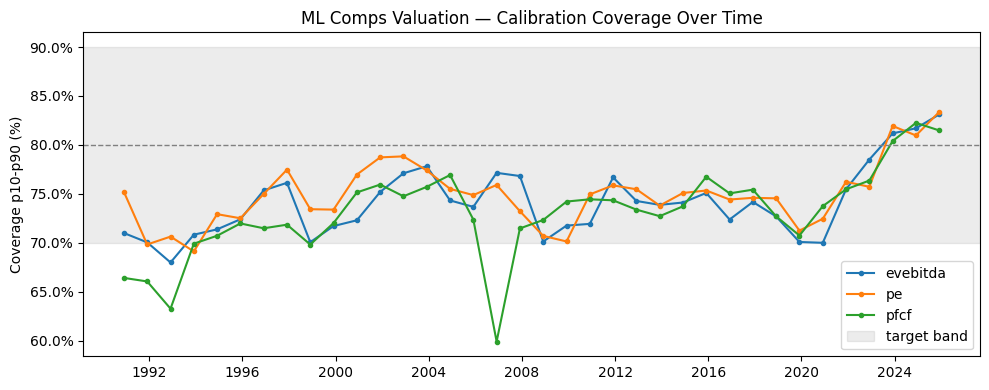

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, grp in folds.groupby("multiple"):
    ax.plot(grp["test_start"], grp["coverage_p10_p90"] * 100, marker="o", markersize=3, label=name)
ax.axhspan(70, 90, color="gray", alpha=0.15, label="target band")
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Coverage p10-p90 (%)")
ax.set_title("ML Comps Valuation — Calibration Coverage Over Time")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
fig.tight_layout()
plt.show()

## Cell 3 — Model RMSE vs. naive sector-median baseline, over time

The model should track *below* the baseline in every fold, not just on average — this
is the fold-level discipline the Phase 3 gate enforces (unlike the aggregate-only
backtest the existing ret_1y model shipped with).

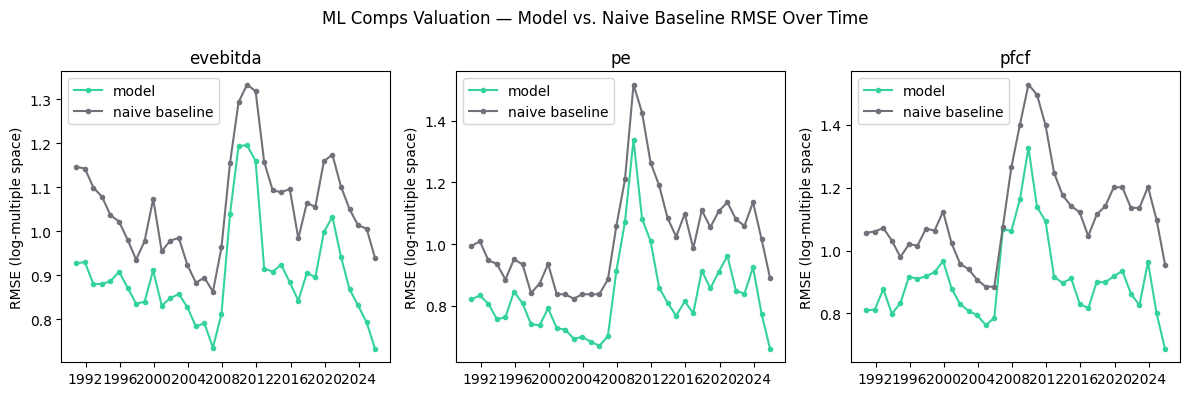

In [3]:
fig, axes = plt.subplots(1, len(folds["multiple"].unique()), figsize=(12, 4), sharey=False)
if len(folds["multiple"].unique()) == 1:
    axes = [axes]
for ax, (name, grp) in zip(axes, folds.groupby("multiple")):
    ax.plot(grp["test_start"], grp["rmse_log"], marker="o", markersize=3, label="model", color="#34d399")
    ax.plot(grp["test_start"], grp["baseline_rmse_log"], marker="o", markersize=3, label="naive baseline", color="#71717a")
    ax.set_title(name)
    ax.set_ylabel("RMSE (log-multiple space)")
    ax.legend()
fig.suptitle("ML Comps Valuation — Model vs. Naive Baseline RMSE Over Time")
fig.tight_layout()
plt.show()

## Cell 4 — Fold win rate (model beats baseline) by year

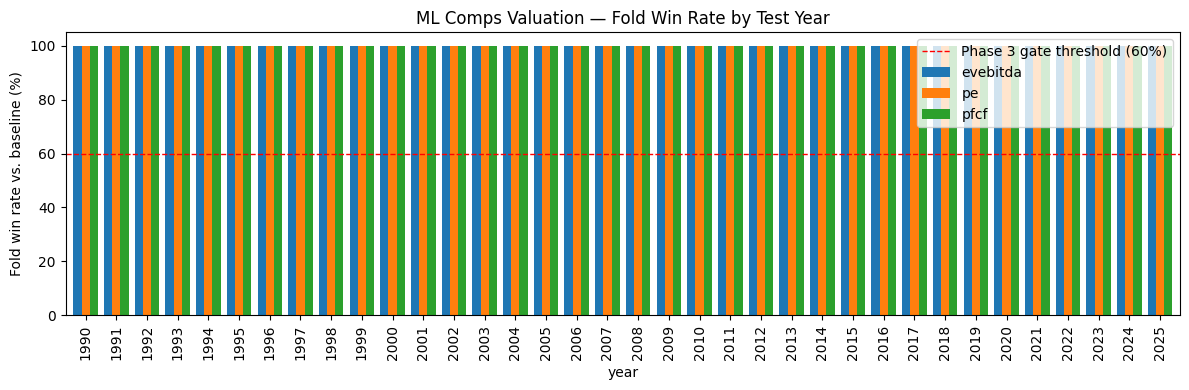

In [4]:
folds["year"] = folds["test_start"].dt.year
win_by_year = folds.groupby(["multiple", "year"])["model_wins"].mean().unstack("multiple") * 100
ax = win_by_year.plot(kind="bar", figsize=(12, 4), width=0.8)
ax.axhline(60, color="red", linestyle="--", linewidth=1, label="Phase 3 gate threshold (60%)")
ax.set_ylabel("Fold win rate vs. baseline (%)")
ax.set_title("ML Comps Valuation — Fold Win Rate by Test Year")
ax.legend()
plt.tight_layout()
plt.show()

## Cell 5 — Feature importance (active production models)

From the currently active `*_latest.joblib` bundles' built-in `feature_importances_`
— a lighter-weight stand-in for full SHAP stability analysis (which would require
refitting across folds); revisit with proper SHAP stability if a specific feature's
importance looks suspicious here.

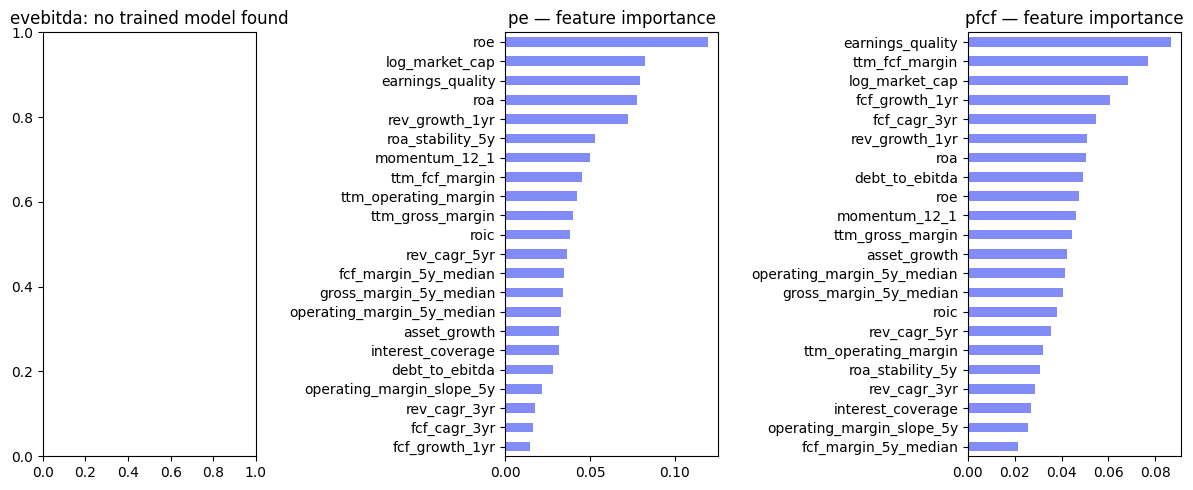

In [5]:
model_dir = ROOT / "data" / "ml_comps_valuation"
targets = sorted(folds["multiple"].unique())

fig, axes = plt.subplots(1, len(targets), figsize=(12, 5))
if len(targets) == 1:
    axes = [axes]
for ax, name in zip(axes, targets):
    path = model_dir / f"{name}_latest.joblib"
    if not path.exists():
        ax.set_title(f"{name}: no trained model found")
        continue
    bundle = joblib.load(path)
    model, feature_cols = bundle["model"], bundle["feature_cols"]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    importances.plot(kind="barh", ax=ax, color="#818cf8")
    ax.set_title(f"{name} — feature importance")
fig.tight_layout()
plt.show()

## Interpreting this notebook

- **Coverage drifting outside [70%, 90%] for several consecutive periods** → the model's
  uncertainty bands are miscalibrated; consider retraining with a shorter/longer rolling
  window or revisiting the quantile objective's hyperparameters.
- **Fold win rate dropping below 60% in recent years** → the model may be losing its edge
  over the naive sector-median baseline as market structure changes; this is the
  early-warning signal the existing ret_1y model never had.
- **RMSE gap between model and baseline narrowing over time** → same signal as above,
  earlier and more continuous.
- **A previously important feature's importance collapsing to ~0** → check for a data
  pipeline issue (e.g. a column silently going all-NaN) before assuming it's a genuine
  regime change.

None of these observations should trigger touching `goal_pe`/`goal_low`/`goal_high` —
see Phase 9 of the plan doc for that separate, deliberately un-started decision.